<a href="https://colab.research.google.com/github/horaharman13/player-performance-prediction-ml/blob/main/%E2%9C%94%20Regularization%20%E2%9C%94%20PCA%20%E2%9C%94%20Cross%20validation%20%E2%9C%94%20Regression%20%E2%9C%94%20Overfitting%20control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

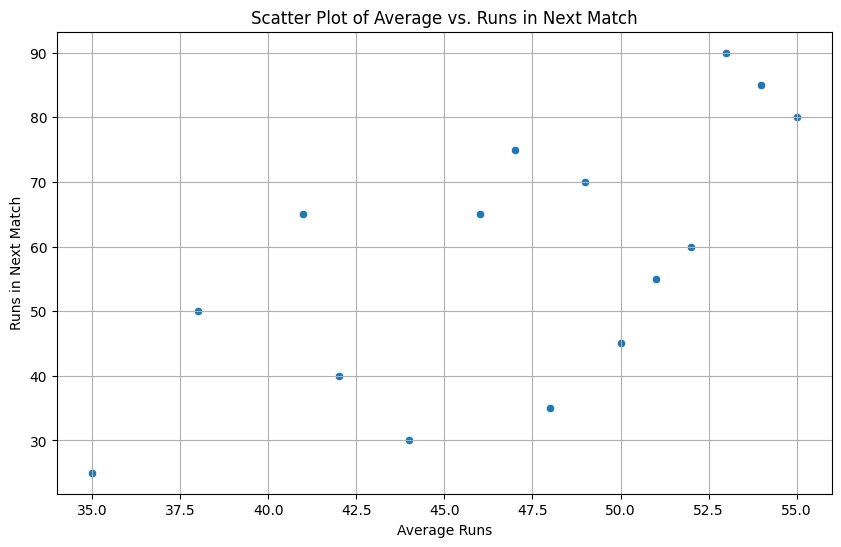

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='average', y='runs_next_match', data=df)
plt.title('Scatter Plot of Average vs. Runs in Next Match')
plt.xlabel('Average Runs')
plt.ylabel('Runs in Next Match')
plt.grid(True)
plt.show()

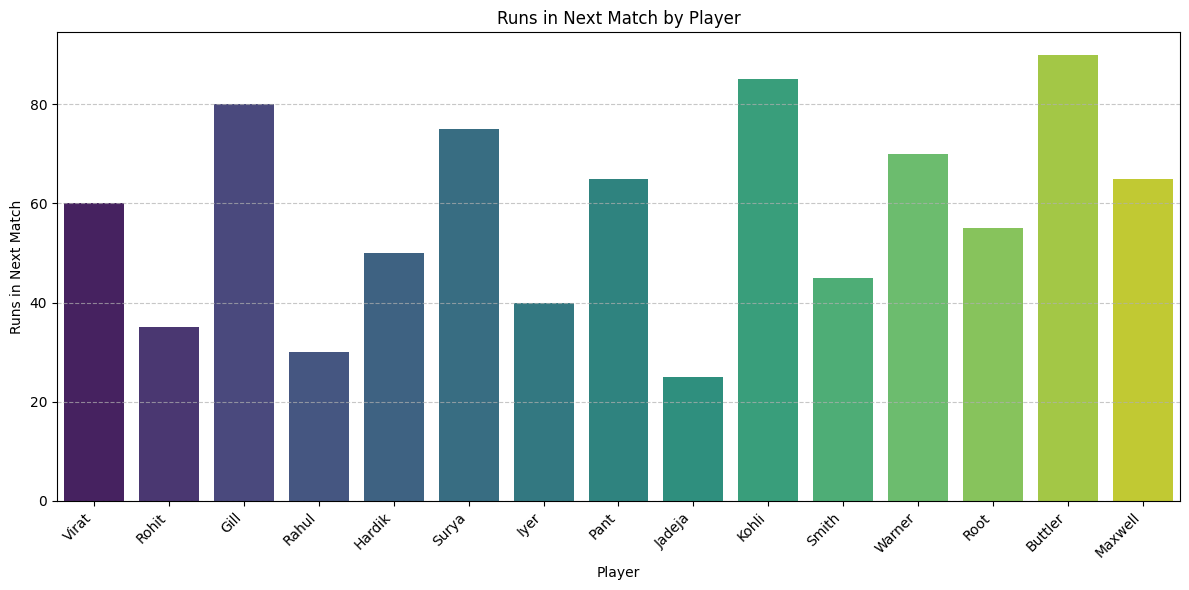

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='player', y='runs_next_match', data=df, palette='viridis', hue='player', legend=False)
plt.title('Runs in Next Match by Player')
plt.xlabel('Player')
plt.ylabel('Runs in Next Match')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import io

data = """player,last5_runs,average,strike_rate,venue_score,pitch_score,weather_score,fitness_score,runs_next_match
Virat,45,52,138,8,7,6,9,60
Rohit,10,48,130,7,6,6,8,35
Gill,70,55,142,9,8,7,9,80
Rahul,25,44,125,6,6,5,7,30
Hardik,40,38,150,7,7,6,8,50
Surya,65,47,160,8,8,7,9,75
Iyer,30,42,132,6,7,6,7,40
Pant,55,46,148,8,7,7,8,65
Jadeja,20,35,120,7,7,6,9,25
Kohli,80,54,140,9,8,7,9,85
Smith,35,50,135,7,7,6,8,45
Warner,60,49,145,8,8,7,8,70
Root,40,51,128,7,6,6,8,55
Buttler,75,53,155,9,8,7,9,90
Maxwell,50,41,165,8,7,6,8,65"""

df = pd.read_csv(io.StringIO(data))
display(df.head())

,player,last5_runs,average,strike_rate,venue_score,pitch_score,weather_score,fitness_score,runs_next_match
0,Virat,45,52,138,8,7,6,9,60
1,Rohit,10,48,130,7,6,6,8,35
2,Gill,70,55,142,9,8,7,9,80
3,Rahul,25,44,125,6,6,5,7,30
4,Hardik,40,38,150,7,7,6,8,50


### Data Overview and Cleaning

First, let's inspect the data types and check for any missing values. All columns seem to be appropriately loaded as numeric types, except for 'player', which is an object type.

All columns appear to be suitable for direct use, and no missing values are present.

In [2]:
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   player           15 non-null     object
 1   last5_runs       15 non-null     int64 
 2   average          15 non-null     int64 
 3   strike_rate      15 non-null     int64 
 4   venue_score      15 non-null     int64 
 5   pitch_score      15 non-null     int64 
 6   weather_score    15 non-null     int64 
 7   fitness_score    15 non-null     int64 
 8   runs_next_match  15 non-null     int64 
dtypes: int64(8), object(1)
memory usage: 1.2+ KB
None

Missing values per column:
player             0
last5_runs         0
average            0
strike_rate        0
venue_score        0
pitch_score        0
weather_score      0
fitness_score      0
runs_next_match    0
dtype: int64


### Numeric Features and Target Column

Based on your requirements, the numeric features and the target column are defined as follows:

*   **Numeric Features**: `last5_runs`, `average`, `strike_rate`, `venue_score`, `pitch_score`, `weather_score`, `fitness_score`.
*   **Target Column**: `runs_next_match`.

In [3]:
numeric_features = ['last5_runs', 'average', 'strike_rate', 'venue_score', 'pitch_score', 'weather_score', 'fitness_score']
target_column = 'runs_next_match'

print(f"Numeric Features: {numeric_features}")
print(f"Target Column: {target_column}")

Numeric Features: ['last5_runs', 'average', 'strike_rate', 'venue_score', 'pitch_score', 'weather_score', 'fitness_score']
Target Column: runs_next_match


# Task
Compare Ridge, Lasso, and ElasticNet regression models for player performance prediction, utilizing PCA for dimensionality reduction, and identify the most effective regularization technique.

## Prepare Data for Modeling

### Subtask:
Split the data into features (X) and target (y). Then, split the dataset into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
To prepare the data for modeling, I need to separate the features (X) and the target variable (y) from the DataFrame `df` and then split them into training and testing sets using `train_test_split`.



In [7]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df[numeric_features]
y = df[target_column]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12, 7)
X_test shape: (3, 7)
y_train shape: (12,)
y_test shape: (3,)


## Apply PCA for Dimensionality Reduction

### Subtask:
Apply Principal Component Analysis (PCA) to the feature set. This step will help in reducing the dimensionality and potentially improving model performance and interpretability.


**Reasoning**:
To apply PCA, I need to first standardize the features using `StandardScaler` to ensure that all features contribute equally to the principal components, and then apply `PCA` to reduce the dimensionality of the scaled data, finally I will print the shapes and explained variance ratio to verify.



In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate PCA with n_components=3
pca = PCA(n_components=3)

# Fit PCA on scaled training data and transform both scaled training and testing data
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape of X_train_pca:", X_train_pca.shape)
print("Shape of X_test_pca:", X_test_pca.shape)
print("Explained variance ratio by principal components:", pca.explained_variance_ratio_)

Shape of X_train_pca: (12, 3)
Shape of X_test_pca: (3, 3)
Explained variance ratio by principal components: [0.67750003 0.13378608 0.10209983]


## Train and Evaluate Ridge Regression with Cross-Validation

### Subtask:
Train a Ridge Regression model using the preprocessed data. Implement cross-validation to tune hyperparameters and evaluate the model's performance based on relevant metrics (e.g., R-squared, RMSE).


**Reasoning**:
To train and evaluate the Ridge Regression model, I will follow the instructions to import necessary modules, set up the model and hyperparameter grid for cross-validation, fit the model, and then calculate and print the evaluation metrics.



In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Instantiate a Ridge regressor
ridge = Ridge()

# Define the hyperparameter grid for alpha
param_grid_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Instantiate GridSearchCV with Ridge model, hyperparameter grid, and cv=5
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2')

# Fit grid_search_ridge to the PCA-transformed training data
grid_search_ridge.fit(X_train_pca, y_train)

# Print the best hyperparameters found
print(f"Best hyperparameters for Ridge: {grid_search_ridge.best_params_}")

# Print the best cross-validation R-squared score
print(f"Best cross-validation R-squared score for Ridge: {grid_search_ridge.best_score_:.4f}")

# Make predictions on the PCA-transformed test data using the best estimator
y_pred_ridge = grid_search_ridge.best_estimator_.predict(X_test_pca)

# Calculate the R-squared score
r2_ridge = r2_score(y_test, y_pred_ridge)

# Calculate the Root Mean Squared Error (RMSE)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Print the R-squared score and RMSE
print(f"Ridge R-squared on test set: {r2_ridge:.4f}")
print(f"Ridge RMSE on test set: {rmse_ridge:.4f}")

Best hyperparameters for Ridge: {'alpha': 0.1}
Best cross-validation R-squared score for Ridge: 0.5394
Ridge R-squared on test set: 0.9352
Ridge RMSE on test set: 2.6146


## Train and Evaluate Lasso Regression with Cross-Validation

### Subtask:
Train a Lasso Regression model. Utilize cross-validation for hyperparameter tuning and evaluate its performance using appropriate regression metrics.


**Reasoning**:
To train and evaluate the Lasso Regression model, I will follow the instructions to import necessary modules, set up the model and hyperparameter grid for cross-validation, fit the model, and then calculate and print the evaluation metrics.



In [10]:
from sklearn.linear_model import Lasso

# Instantiate a Lasso regressor
lasso = Lasso()

# Define the hyperparameter grid for alpha
param_grid_lasso = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Instantiate GridSearchCV with Lasso model, hyperparameter grid, and cv=5
grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='r2')

# Fit grid_search_lasso to the PCA-transformed training data
grid_search_lasso.fit(X_train_pca, y_train)

# Print the best hyperparameters found
print(f"Best hyperparameters for Lasso: {grid_search_lasso.best_params_}")

# Print the best cross-validation R-squared score
print(f"Best cross-validation R-squared score for Lasso: {grid_search_lasso.best_score_:.4f}")

# Make predictions on the PCA-transformed test data using the best estimator
y_pred_lasso = grid_search_lasso.best_estimator_.predict(X_test_pca)

# Calculate the R-squared score
r2_lasso = r2_score(y_test, y_pred_lasso)

# Calculate the Root Mean Squared Error (RMSE)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Print the R-squared score and RMSE
print(f"Lasso R-squared on test set: {r2_lasso:.4f}")
print(f"Lasso RMSE on test set: {rmse_lasso:.4f}")

Best hyperparameters for Lasso: {'alpha': 0.1}
Best cross-validation R-squared score for Lasso: 0.5322
Lasso R-squared on test set: 0.9340
Lasso RMSE on test set: 2.6390


## Train and Evaluate ElasticNet Regression with Cross-Validation

### Subtask:
Train an ElasticNet Regression model. Implement cross-validation to tune hyperparameters and evaluate the model's performance based on relevant metrics (e.g., R-squared, RMSE).

**Reasoning**:
To train and evaluate the ElasticNet Regression model, I will follow the instructions to import necessary modules, set up the model and hyperparameter grid for cross-validation, fit the model, and then calculate and print the evaluation metrics.



In [11]:
from sklearn.linear_model import ElasticNet

# Instantiate an ElasticNet regressor
elasticnet = ElasticNet(random_state=42)

# Define the hyperparameter grid for alpha and l1_ratio
param_grid_elasticnet = {
    'alpha': [0.1, 1.0, 10.0, 100.0],
    'l1_ratio': [0.1, 0.5, 0.9]
}

# Instantiate GridSearchCV with ElasticNet model, hyperparameter grid, and cv=5
grid_search_elasticnet = GridSearchCV(elasticnet, param_grid_elasticnet, cv=5, scoring='r2')

# Fit grid_search_elasticnet to the PCA-transformed training data
grid_search_elasticnet.fit(X_train_pca, y_train)

# Print the best hyperparameters found
print(f"Best hyperparameters for ElasticNet: {grid_search_elasticnet.best_params_}")

# Print the best cross-validation R-squared score
print(f"Best cross-validation R-squared score for ElasticNet: {grid_search_elasticnet.best_score_:.4f}")

# Make predictions on the PCA-transformed test data using the best estimator
y_pred_elasticnet = grid_search_elasticnet.best_estimator_.predict(X_test_pca)

# Calculate the R-squared score
r2_elasticnet = r2_score(y_test, y_pred_elasticnet)

# Calculate the Root Mean Squared Error (RMSE)
rmse_elasticnet = np.sqrt(mean_squared_error(y_test, y_pred_elasticnet))

# Print the R-squared score and RMSE
print(f"ElasticNet R-squared on test set: {r2_elasticnet:.4f}")
print(f"ElasticNet RMSE on test set: {rmse_elasticnet:.4f}")

Best hyperparameters for ElasticNet: {'alpha': 0.1, 'l1_ratio': 0.1}
Best cross-validation R-squared score for ElasticNet: 0.5373
ElasticNet R-squared on test set: 0.9417
ElasticNet RMSE on test set: 2.4805


## Compare Model Performance

### Subtask:
Compare the performance of Ridge, Lasso, and ElasticNet regression models based on their R-squared and RMSE values to identify the most effective regularization technique for player performance prediction.

**Reasoning**:
All three regression models have been trained and evaluated. I will now create a DataFrame to consolidate and display their R-squared and RMSE values for a clear comparison, thus addressing the subtask of comparing model performance.



In [12]:
import pandas as pd

# Create a dictionary to store the results
results = {
    'Model': ['Ridge', 'Lasso', 'ElasticNet'],
    'R-squared (Test)': [r2_ridge, r2_lasso, r2_elasticnet],
    'RMSE (Test)': [rmse_ridge, rmse_lasso, rmse_elasticnet]
}

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Print the comparison table
print("\nModel Performance Comparison:")
print(results_df.round(4))



Model Performance Comparison:
        Model  R-squared (Test)  RMSE (Test)
0       Ridge            0.9352       2.6146
1       Lasso            0.9340       2.6390
2  ElasticNet            0.9417       2.4805


## Final Task

### Subtask:
Summarize the findings from the model comparison and identify the most effective regularization technique for player performance prediction in this dataset.


## Summary:

### Q&A
The most effective regularization technique for player performance prediction in this dataset, after PCA dimensionality reduction, is ElasticNet Regression.

### Data Analysis Key Findings
*   The initial dataset, comprising 7 numerical features and a target variable, was successfully split into training and testing sets (12 and 3 samples respectively).
*   Principal Component Analysis (PCA) reduced the feature dimensionality from 7 to 3 components. These three components explained 67.75%, 13.38%, and 10.21% of the variance respectively, indicating a substantial capture of information.
*   **Ridge Regression** achieved an R-squared of 0.9352 and an RMSE of 2.6146 on the test set, with the optimal alpha hyperparameter identified as 0.1.
*   **Lasso Regression** yielded an R-squared of 0.9340 and an RMSE of 2.6390 on the test set, also with an optimal alpha of 0.1.
*   **ElasticNet Regression** demonstrated the best performance among the three models with an R-squared of 0.9417 and an RMSE of 2.4805 on the test set. Its optimal hyperparameters were an alpha of 0.1 and an l1\_ratio of 0.1.

### Insights or Next Steps
*   ElasticNet, which combines L1 and L2 regularization, offers the best predictive performance for player performance in this reduced-dimensional space. This suggests that both feature selection (L1) and coefficient shrinkage (L2) are beneficial.
*   Further hyperparameter tuning for the ElasticNet model, particularly exploring a wider range of `l1_ratio` values and more granular `alpha` values around the optimal point, could potentially lead to even better performance.
